In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [ ]:
import os
import sys

print("Python:", sys.version)

print("\nKaggle input:")
print(os.listdir("/kaggle/input"))

print("\nWorking directory:")
print(os.listdir("/kaggle/working"))

In [ ]:
import os

print("========== KAGGLE INPUT ==========")

for item in os.listdir("/kaggle/input"):
    print(item)

print("\n========== ALL DIRECTORIES ==========")

for root, dirs, files in os.walk("/kaggle/input"):
    print(root)

In [ ]:
import os

print("========== KAGGLE INPUT ==========")

for item in os.listdir("/kaggle/input"):
    print(item)

print("\n========== DATASET DIRECTORIES ==========")

for root, dirs, files in os.walk("/kaggle/input"):
    print(root)

In [ ]:
import os

print("========== ATTACHED INPUTS ==========")

for item in os.listdir("/kaggle/input"):
    print(item)

print("\n========== FIRST-LEVEL CONTENT ==========")

for item in os.listdir("/kaggle/input"):
    path = os.path.join("/kaggle/input", item)

    if os.path.isdir(path):
        print(f"\n📁 {item}/")
        try:
            contents = os.listdir(path)
            for x in contents[:15]:
                print("   ", x)
            if len(contents) > 15:
                print(f"   ... and {len(contents)-15} more")
        except Exception as e:
            print("   Error:", e)
            

In [ ]:
import os

base = "/kaggle/input/datasets"

for owner in os.listdir(base):
    owner_path = os.path.join(base, owner)

    print(f"\n========== {owner} ==========")

    if os.path.isdir(owner_path):
        for item in os.listdir(owner_path):
            item_path = os.path.join(owner_path, item)

            if os.path.isdir(item_path):
                print(f"📁 {item}/")
                
                # Show what's inside this dataset folder
                for subitem in os.listdir(item_path)[:20]:
                    print(f"   └── {subitem}")
            else:
                print(f"📄 {item}")
                

In [ ]:
import os

ff_path = "/kaggle/input/datasets/xdxd003/ff-c23/FaceForensics++_C23"

print("FaceForensics++ C23 folders:\n")

for item in sorted(os.listdir(ff_path)):
    path = os.path.join(ff_path, item)

    if os.path.isdir(path):
        print(f"📁 {item}/")
    else:
        print(f"📄 {item}")

In [ ]:
import os

cel_path = "/kaggle/input/datasets/reubensuju/celeb-df-v2"

print("Celeb-DF folders/files:\n")

for item in sorted(os.listdir(cel_path)):
    path = os.path.join(cel_path, item)

    if os.path.isdir(path):
        print(f"📁 {item}/")
    else:
        print(f"📄 {item}")

In [ ]:

import pandas as pd

csv_url = "https://raw.githubusercontent.com/SrishtiKumari08/deepfake-detector-project/refs/heads/master/logs/clean_video_list.csv"

df = pd.read_csv(csv_url)

print("Number of rows:", len(df))
print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 10 rows:")
display(df.head(10))

In [ ]:
import os
import pandas as pd

# ============================================================
# 1. Load the clean video list
# ============================================================

csv_url = "https://raw.githubusercontent.com/SrishtiKumari08/deepfake-detector-project/refs/heads/master/logs/clean_video_list.csv"

df = pd.read_csv(csv_url)

print("Total videos in clean_video_list.csv:", len(df))


# ============================================================
# 2. Kaggle dataset locations
# ============================================================

CELEB_ROOT = "/kaggle/input/datasets/reubensuju/celeb-df-v2"

FF_ROOT = "/kaggle/input/datasets/xdxd003/ff-c23/FaceForensics++_C23"


# ============================================================
# 3. Build an index of actual videos available in Kaggle
# ============================================================

print("\nIndexing Celeb-DF videos...")

In [ ]:
import os

print("Celeb-DF root exists:", os.path.exists(CELEB_ROOT))
print("FF++ root exists:", os.path.exists(FF_ROOT))

print("\nCeleb-DF contents:")
print(os.listdir(CELEB_ROOT))

print("\nFF++ contents:")
print(os.listdir(FF_ROOT))

In [ ]:
import os
import pandas as pd

# ============================================================
# 1. Load clean video list
# ============================================================

csv_url = "https://raw.githubusercontent.com/SrishtiKumari08/deepfake-detector-project/refs/heads/master/logs/clean_video_list.csv"

df = pd.read_csv(csv_url)

print("Total videos in clean CSV:", len(df))


# ============================================================
# 2. Dataset roots
# ============================================================

CELEB_ROOT = "/kaggle/input/datasets/reubensuju/celeb-df-v2"
FF_ROOT = "/kaggle/input/datasets/xdxd003/ff-c23/FaceForensics++_C23"


# ============================================================
# 3. Create a filename/path index of all actual videos
# ============================================================

print("\nScanning Celeb-DF...")

celeb_files = {}

for root, dirs, files in os.walk(CELEB_ROOT):
    for file in files:
        if file.lower().endswith(".mp4"):
            full_path = os.path.join(root, file)
            
            # Relative path inside Celeb-DF
            rel_path = os.path.relpath(full_path, CELEB_ROOT)
            
            # Normalize path separators
            rel_path = rel_path.replace("\\", "/")
            
            celeb_files[rel_path] = full_path


print("Celeb-DF videos found:", len(celeb_files))


print("\nScanning FaceForensics++ C23...")

ff_files = {}

for root, dirs, files in os.walk(FF_ROOT):
    for file in files:
        if file.lower().endswith(".mp4"):
            full_path = os.path.join(root, file)
            
            # Relative path inside FF++
            rel_path = os.path.relpath(full_path, FF_ROOT)
            
            # Normalize path separators
            rel_path = rel_path.replace("\\", "/")
            
            ff_files[rel_path] = full_path


print("FF++ videos found:", len(ff_files))


# ============================================================
# 4. Match every CSV entry
# ============================================================

found_paths = []
missing_paths = []
dataset_names = []

for csv_path in df["video_path"]:

    # Convert Windows backslashes to Linux-style slashes
    clean_path = csv_path.replace("\\", "/")

    # --------------------------------------------------------
    # Celeb-DF
    # --------------------------------------------------------
    if clean_path.startswith("data/raw/cel/"):

        relative_path = clean_path.replace(
            "data/raw/cel/",
            "",
            1
        )

        if relative_path in celeb_files:
            found_paths.append(celeb_files[relative_path])
            dataset_names.append("Celeb-DF")
        else:
            found_paths.append(None)
            dataset_names.append("MISSING")

    # --------------------------------------------------------
    # FaceForensics++
    # --------------------------------------------------------
    elif clean_path.startswith("data/raw/FaceForensics++_C23/"):

        relative_path = clean_path.replace(
            "data/raw/FaceForensics++_C23/",
            "",
            1
        )

        if relative_path in ff_files:
            found_paths.append(ff_files[relative_path])
            dataset_names.append("FaceForensics++")
        else:
            found_paths.append(None)
            dataset_names.append("MISSING")

    # --------------------------------------------------------
    # Unexpected path
    # --------------------------------------------------------
    else:
        found_paths.append(None)
        dataset_names.append("UNKNOWN")


# ============================================================
# 5. Add results to dataframe
# ============================================================

df["kaggle_path"] = found_paths
df["dataset"] = dataset_names

found_count = df["kaggle_path"].notna().sum()
missing_count = df["kaggle_path"].isna().sum()


# ============================================================
# 6. Print final verification
# ============================================================

print("\n" + "=" * 50)
print("VIDEO MATCHING RESULT")
print("=" * 50)

print("Total CSV videos :", len(df))
print("Found in Kaggle  :", found_count)
print("Missing          :", missing_count)

print("\nDataset breakdown:")
print(df["dataset"].value_counts())


# ============================================================
# 7. Show missing files, if any
# ============================================================

if missing_count > 0:
    print("\nFirst 20 missing videos:")
    display(df[df["kaggle_path"].isna()][
        ["video_path", "dataset"]
    ].head(20))
else:
    print("\n🎉 ALL 13,529 VIDEOS WERE FOUND!")

In [ ]:
# Pick the first verified video
test_video = df.iloc[0]["kaggle_path"]

print("Test video:")
print(test_video)

print("\nDataset:")
print(df.iloc[0]["dataset"])

print("\nFile exists:")
print(os.path.exists(test_video))

print("\nFile size:")
print(round(os.path.getsize(test_video) / (1024 * 1024), 2), "MB")

In [ ]:
import cv2

cap = cv2.VideoCapture(test_video)

if not cap.isOpened():
    print("❌ Could not open video")
else:
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps = cap.get(cv2.CAP_PROP_FPS)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    print("✅ Video opened successfully")
    print("Frames :", frame_count)
    print("FPS    :", fps)
    print("Width  :", width)
    print("Height :", height)

    # Read first frame
    success, frame = cap.read()

    print("First frame readable:", success)

cap.release()

In [ ]:
!pip install facenet-pytorch -q

In [ ]:
import cv2
import torch
import numpy as np

print("OpenCV:", cv2.__version__)
print("NumPy:", np.__version__)
print("PyTorch:", torch.__version__)

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

In [ ]:
from facenet_pytorch import MTCNN

mtcnn = MTCNN(
    keep_all=True,
    device=device,
    min_face_size=40,
    thresholds=[0.6, 0.7, 0.7]
)

print("✅ MTCNN loaded successfully")

In [ ]:
import torch
import torchvision
import PIL
import numpy

print("Torch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("Pillow:", PIL.__version__)
print("NumPy:", numpy.__version__)

In [ ]:
!pip install --force-reinstall --no-cache-dir "Pillow==10.4.0" -q

In [ ]:
!pip install --force-reinstall --no-cache-dir "Pillow==10.2.0" -q

In [ ]:
import importlib.metadata as metadata

for package in ["torch", "torchvision", "facenet-pytorch", "Pillow", "numpy"]:
    try:
        print(f"{package}: {metadata.version(package)}")
    except Exception as e:
        print(f"{package}: {e}")

In [ ]:
import torch
import torchvision
from PIL import Image

print("Torch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("Pillow:", Image.__version__)
print("CUDA:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

print("✅ Imports working")

In [ ]:
import torch
from facenet_pytorch import MTCNN

# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

# Create face detector
mtcnn = MTCNN(
    keep_all=True,
    device=device,
    min_face_size=40,
    thresholds=[0.6, 0.7, 0.7]
)

print("✅ MTCNN loaded successfully")

In [ ]:
import os

test_video = "/kaggle/input/datasets/reubensuju/celeb-df-v2/Celeb-real/id0_0000.mp4"

print("Test video:", test_video)
print("Exists:", os.path.exists(test_video))

In [ ]:
import cv2
from PIL import Image

# Open video
cap = cv2.VideoCapture(test_video)

# Read first frame
success, frame = cap.read()

cap.release()

if not success:
    raise RuntimeError("❌ Could not read first frame")

print("Frame read successfully")
print("Frame shape:", frame.shape)

# OpenCV BGR → RGB
frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

# Convert to PIL image
image = Image.fromarray(frame_rgb)

# Detect faces
boxes, probabilities = mtcnn.detect(image)

print("\nFaces detected:", 0 if boxes is None else len(boxes))

print("\nBounding boxes:")
print(boxes)

print("\nConfidence scores:")
print(probabilities)

In [ ]:
import os
import pandas as pd

# ==========================================
# STEP 4 PATHS
# ==========================================

# CSV created by Steps 1–3
CSV_URL = "https://raw.githubusercontent.com/SrishtiKumari08/deepfake-detector-project/refs/heads/master/logs/clean_video_list.csv"

# Dataset roots on Kaggle
CELEB_ROOT = "/kaggle/input/datasets/reubensuju/celeb-df-v2"
FF_ROOT = "/kaggle/input/datasets/xdxd003/ff-c23/FaceForensics++_C23"

# Output directory
OUTPUT_ROOT = "/kaggle/working/step4_faces"

os.makedirs(OUTPUT_ROOT, exist_ok=True)

print("CSV:", CSV_URL)
print("Celeb-DF:", os.path.exists(CELEB_ROOT))
print("FF++:", os.path.exists(FF_ROOT))
print("Output:", OUTPUT_ROOT)

In [ ]:
def get_kaggle_video_path(relative_path):
    """
    Convert the path from clean_video_list.csv
    into the corresponding Kaggle dataset path.
    """

    # Normalize Windows backslashes
    path = relative_path.replace("\\", "/")

    # -----------------------------
    # Celeb-DF
    # -----------------------------
    if "data/raw/cel/" in path:

        relative = path.split("data/raw/cel/", 1)[1]

        return os.path.join(
            CELEB_ROOT,
            relative
        )

    # -----------------------------
    # FaceForensics++ C23
    # -----------------------------
    elif "data/raw/FaceForensics++_C23/" in path:

        relative = path.split(
            "data/raw/FaceForensics++_C23/",
            1
        )[1]

        return os.path.join(
            FF_ROOT,
            relative
        )

    return None

In [ ]:
df = pd.read_csv(CSV_URL)

print("Total verified videos:", len(df))
print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5:")
display(df.head())

In [ ]:
df["kaggle_path"] = df["video_path"].apply(
    get_kaggle_video_path
)

df["exists"] = df["kaggle_path"].apply(
    os.path.exists
)

print("Total:", len(df))
print("Found:", df["exists"].sum())
print("Missing:", (~df["exists"]).sum())

In [ ]:
import torch
from facenet_pytorch import MTCNN

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

mtcnn = MTCNN(
    keep_all=True,
    device=device,
    min_face_size=40,
    thresholds=[0.6, 0.7, 0.7]
)

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

print("✅ MTCNN ready")

In [ ]:
!pip install -q facenet-pytorch==2.6.0 Pillow==10.2.0

In [ ]:
import torch
import torchvision
import PIL
import facenet_pytorch

print("Torch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("Pillow:", PIL.__version__)
print("facenet-pytorch:", facenet_pytorch.__version__)

print("CUDA:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

In [ ]:
!pip uninstall -y torchvision torch torchaudio -q

In [ ]:
!pip install -q torch==2.2.2 torchvision==0.17.2 torchaudio==2.2.2 \
    --index-url https://download.pytorch.org/whl/cu121

In [ ]:
import torch
import torchvision
import PIL
import facenet_pytorch

print("Torch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("Pillow:", PIL.__version__)
print("FaceNet-PyTorch:", facenet_pytorch.__version__)

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

print("✅ All imports working")

In [1]:
import sys
print(sys.version)

!pip show torch torchvision torchaudio facenet-pytorch pillow

3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Name: torch
Version: 2.2.2+cu121
Summary: Tensors and Dynamic neural networks in Python with strong GPU acceleration
Home-page: https://pytorch.org/
Author: PyTorch Team
Author-email: packages@pytorch.org
License: BSD-3
Location: /usr/local/lib/python3.12/dist-packages
Requires: filelock, fsspec, jinja2, networkx, nvidia-cublas-cu12, nvidia-cuda-cupti-cu12, nvidia-cuda-nvrtc-cu12, nvidia-cuda-runtime-cu12, nvidia-cudnn-cu12, nvidia-cufft-cu12, nvidia-curand-cu12, nvidia-cusolver-cu12, nvidia-cusparse-cu12, nvidia-nccl-cu12, nvidia-nvtx-cu12, sympy, typing-extensions
Required-by: accelerate, easyocr, facenet-pytorch, fastai, kornia, peft, pytorch-ignite, pytorch-lightning, sentence-transformers, timm, torchaudio, torchdata, torchmetrics, torchvision
---
Name: torchvision
Version: 0.17.2+cu121
Summary: image and video datasets and models for torch deep learning
Home-page: https://github.com/pytorch/vision
Author: PyTorch Core Team
Author

In [2]:
import torch
import torchvision

print("Torch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

print("✅ Torchvision imported successfully")

Torch: 2.2.2+cu121
Torchvision: 0.17.2+cu121
CUDA available: True
GPU: Tesla T4
✅ Torchvision imported successfully


In [3]:
from facenet_pytorch import MTCNN

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

mtcnn = MTCNN(
    keep_all=True,
    device=device,
    post_process=False
)

print("Device:", device)
print("✅ MTCNN loaded successfully")

Device: cuda
✅ MTCNN loaded successfully


In [4]:
import os
import cv2
import pandas as pd
import numpy as np
from PIL import Image
from tqdm.auto import tqdm

# --------------------------------------------------
# 1. Load the verified video list
# --------------------------------------------------

CSV_PATH = "/kaggle/working/clean_video_list.csv"

df = pd.read_csv(CSV_PATH)

print("Total videos:", len(df))
print(df.head())

FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/working/clean_video_list.csv'

In [5]:
import pandas as pd

CSV_URL = "https://raw.githubusercontent.com/SrishtiKumari08/deepfake-detector-project/master/logs/clean_video_list.csv"

df = pd.read_csv(CSV_URL)

print("Total videos:", len(df))
print("Columns:", df.columns.tolist())
print("\nFirst 10 rows:")
display(df.head(10))

Total videos: 13529
Columns: ['video_path']

First 10 rows:


,video_path
0,data/raw\cel\Celeb-real\id0_0000.mp4
1,data/raw\cel\Celeb-real\id0_0001.mp4
2,data/raw\cel\Celeb-real\id0_0002.mp4
3,data/raw\cel\Celeb-real\id0_0003.mp4
4,data/raw\cel\Celeb-real\id0_0004.mp4
5,data/raw\cel\Celeb-real\id0_0005.mp4
6,data/raw\cel\Celeb-real\id0_0006.mp4
7,data/raw\cel\Celeb-real\id0_0007.mp4
8,data/raw\cel\Celeb-real\id0_0008.mp4
9,data/raw\cel\Celeb-real\id0_0009.mp4


In [6]:
import os
import cv2
import numpy as np
from PIL import Image
from tqdm.auto import tqdm

# Output directory
OUTPUT_DIR = "/kaggle/working/step4_faces"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Output directory:", OUTPUT_DIR)
print("✅ Ready for Step 4")

Output directory: /kaggle/working/step4_faces
✅ Ready for Step 4


In [7]:
print("Celeb-DF root:", CELEB_ROOT)
print("FF++ root:", FF_ROOT)

print("Celeb-DF exists:", os.path.exists(CELEB_ROOT))
print("FF++ exists:", os.path.exists(FF_ROOT))

NameError: name 'CELEB_ROOT' is not defined

In [9]:
import os

# Kaggle dataset roots
CELEB_ROOT = "/kaggle/input/datasets/reubensuju/celeb-df-v2"
FF_ROOT = "/kaggle/input/datasets/xdxd003/ff-c23/FaceForensics++_C23"

print("Celeb-DF root:", CELEB_ROOT)
print("FF++ root:", FF_ROOT)

print("Celeb-DF exists:", os.path.exists(CELEB_ROOT))
print("FF++ exists:", os.path.exists(FF_ROOT))

Celeb-DF root: /kaggle/input/datasets/reubensuju/celeb-df-v2
FF++ root: /kaggle/input/datasets/xdxd003/ff-c23/FaceForensics++_C23
Celeb-DF exists: True
FF++ exists: True


In [11]:
def get_kaggle_video_path(relative_path):
    """
    Convert the path from clean_video_list.csv
    into the corresponding Kaggle dataset path.
    """

    # Normalize Windows backslashes
    path = relative_path.replace("\\", "/")

    # Celeb-DF
    if "data/raw/cel/" in path:

        relative = path.split("data/raw/cel/", 1)[1]

        return os.path.join(
            CELEB_ROOT,
            relative
        )

    # FaceForensics++ C23
    elif "data/raw/FaceForensics++_C23/" in path:

        relative = path.split(
            "data/raw/FaceForensics++_C23/",
            1
        )[1]

        return os.path.join(
            FF_ROOT,
            relative
        )

    return None

print("✅ Path conversion function ready")

✅ Path conversion function ready


In [12]:
test_paths = df["video_path"].head(10).tolist()

for p in test_paths:
    kaggle_path = get_kaggle_video_path(p)

    print("CSV path :", p)
    print("Kaggle   :", kaggle_path)
    print("Exists   :", os.path.exists(kaggle_path))
    print("-" * 70)

CSV path : data/raw\cel\Celeb-real\id0_0000.mp4
Kaggle   : /kaggle/input/datasets/reubensuju/celeb-df-v2/Celeb-real/id0_0000.mp4
Exists   : True
----------------------------------------------------------------------
CSV path : data/raw\cel\Celeb-real\id0_0001.mp4
Kaggle   : /kaggle/input/datasets/reubensuju/celeb-df-v2/Celeb-real/id0_0001.mp4
Exists   : True
----------------------------------------------------------------------
CSV path : data/raw\cel\Celeb-real\id0_0002.mp4
Kaggle   : /kaggle/input/datasets/reubensuju/celeb-df-v2/Celeb-real/id0_0002.mp4
Exists   : True
----------------------------------------------------------------------
CSV path : data/raw\cel\Celeb-real\id0_0003.mp4
Kaggle   : /kaggle/input/datasets/reubensuju/celeb-df-v2/Celeb-real/id0_0003.mp4
Exists   : True
----------------------------------------------------------------------
CSV path : data/raw\cel\Celeb-real\id0_0004.mp4
Kaggle   : /kaggle/input/datasets/reubensuju/celeb-df-v2/Celeb-real/id0_0004.mp4
Exists 

In [13]:
import os

OUTPUT_DIR = "/kaggle/working/step4_faces"
FACES_DIR = os.path.join(OUTPUT_DIR, "faces")

os.makedirs(FACES_DIR, exist_ok=True)

print("Output directory:", OUTPUT_DIR)
print("Faces directory:", FACES_DIR)
print("✅ Output folders ready")

Output directory: /kaggle/working/step4_faces
Faces directory: /kaggle/working/step4_faces/faces
✅ Output folders ready


In [14]:
import cv2
import pandas as pd
import numpy as np
from PIL import Image
from tqdm.auto import tqdm

# -----------------------------
# Settings for TEST
# -----------------------------

NUM_TEST_VIDEOS = 10

# Process every 10th frame for the test
FRAME_INTERVAL = 10

# Minimum face confidence
MIN_CONFIDENCE = 0.90

results = []

test_df = df.head(NUM_TEST_VIDEOS)

print("Videos to test:", len(test_df))
print("=" * 60)

for video_index, row in tqdm(
    test_df.iterrows(),
    total=len(test_df),
    desc="Step 4 test"
):

    csv_path = row["video_path"]
    video_path = get_kaggle_video_path(csv_path)

    if video_path is None or not os.path.exists(video_path):
        print("❌ Missing:", csv_path)
        continue

    cap = cv2.VideoCapture(video_path)

    if not cap.isOpened():
        print("❌ Could not open:", video_path)
        continue

    frame_number = 0
    frames_checked = 0
    faces_found = 0

    while True:

        ret, frame = cap.read()

        if not ret:
            break

        # Only process every 10th frame
        if frame_number % FRAME_INTERVAL != 0:
            frame_number += 1
            continue

        frames_checked += 1

        # BGR → RGB
        rgb_frame = cv2.cvtColor(
            frame,
            cv2.COLOR_BGR2RGB
        )

        image = Image.fromarray(rgb_frame)

        # MTCNN detection
        boxes, probabilities = mtcnn.detect(image)

        if boxes is None or probabilities is None:
            frame_number += 1
            continue

        # Find confident faces
        valid_faces = []

        for box, confidence in zip(
            boxes,
            probabilities
        ):

            if confidence is None:
                continue

            if confidence < MIN_CONFIDENCE:
                continue

            x1, y1, x2, y2 = box

            width = max(0, x2 - x1)
            height = max(0, y2 - y1)

            area = width * height

            valid_faces.append(
                (area, box, confidence)
            )

        if not valid_faces:
            frame_number += 1
            continue

        # Largest face = main face
        valid_faces.sort(
            key=lambda x: x[0],
            reverse=True
        )

        area, box, confidence = valid_faces[0]

        x1, y1, x2, y2 = box

        h, w = rgb_frame.shape[:2]

        x1 = max(0, int(x1))
        y1 = max(0, int(y1))
        x2 = min(w, int(x2))
        y2 = min(h, int(y2))

        if x2 <= x1 or y2 <= y1:
            frame_number += 1
            continue

        # Crop largest face
        face = rgb_frame[y1:y2, x1:x2]

        if face.size == 0:
            frame_number += 1
            continue

        # Create unique folder for each video
        video_name = os.path.splitext(
            os.path.basename(csv_path)
        )[0]

        video_output_dir = os.path.join(
            FACES_DIR,
            video_name
        )

        os.makedirs(
            video_output_dir,
            exist_ok=True
        )

        face_filename = (
            f"frame_{frame_number:06d}.jpg"
        )

        face_path = os.path.join(
            video_output_dir,
            face_filename
        )

        Image.fromarray(face).save(
            face_path,
            quality=95
        )

        faces_found += 1

        results.append({
            "video_path": csv_path,
            "frame_number": frame_number,
            "face_path": face_path,
            "confidence": float(confidence),
            "x1": x1,
            "y1": y1,
            "x2": x2,
            "y2": y2,
            "face_width": x2 - x1,
            "face_height": y2 - y1
        })

        frame_number += 1

    cap.release()

    print(
        f"{video_index + 1}/{len(test_df)} | "
        f"frames checked: {frames_checked} | "
        f"faces saved: {faces_found}"
    )

# -----------------------------
# Save metadata
# -----------------------------

results_df = pd.DataFrame(results)

metadata_path = os.path.join(
    OUTPUT_DIR,
    "step4_test_metadata.csv"
)

results_df.to_csv(
    metadata_path,
    index=False
)

print("\n" + "=" * 60)
print("✅ STEP 4 TEST COMPLETE")
print("=" * 60)

print("Videos tested:", len(test_df))
print("Face crops saved:", len(results_df))
print("Metadata file:", metadata_path)

if len(results_df) > 0:
    print(
        "Average confidence:",
        round(results_df["confidence"].mean(), 4)
    )

    print("\nFirst 5 results:")
    display(results_df.head())

Videos to test: 10


Step 4 test:   0%|          | 0/10 [00:00<?, ?it/s]

1/10 | frames checked: 47 | faces saved: 47
2/10 | frames checked: 31 | faces saved: 31
3/10 | frames checked: 35 | faces saved: 35
4/10 | frames checked: 53 | faces saved: 53
5/10 | frames checked: 33 | faces saved: 33
6/10 | frames checked: 46 | faces saved: 46
7/10 | frames checked: 54 | faces saved: 54
8/10 | frames checked: 48 | faces saved: 48
9/10 | frames checked: 47 | faces saved: 47
10/10 | frames checked: 52 | faces saved: 52

✅ STEP 4 TEST COMPLETE
Videos tested: 10
Face crops saved: 446
Metadata file: /kaggle/working/step4_faces/step4_test_metadata.csv
Average confidence: 0.9999

First 5 results:


,video_path,frame_number,face_path,confidence,x1,y1,x2,y2,face_width,face_height
0,data/raw\cel\Celeb-real\id0_0000.mp4,0,/kaggle/working/step4_faces/faces/raw\cel\Cele...,1.000000,555,112,642,226,87,114
1,data/raw\cel\Celeb-real\id0_0000.mp4,10,/kaggle/working/step4_faces/faces/raw\cel\Cele...,0.999982,555,114,639,226,84,112
2,data/raw\cel\Celeb-real\id0_0000.mp4,20,/kaggle/working/step4_faces/faces/raw\cel\Cele...,0.999990,545,111,629,224,84,113
3,data/raw\cel\Celeb-real\id0_0000.mp4,30,/kaggle/working/step4_faces/faces/raw\cel\Cele...,0.999985,520,110,605,216,85,106
4,data/raw\cel\Celeb-real\id0_0000.mp4,40,/kaggle/working/step4_faces/faces/raw\cel\Cele...,0.999999,497,108,583,216,86,108


Total face crops found: 446


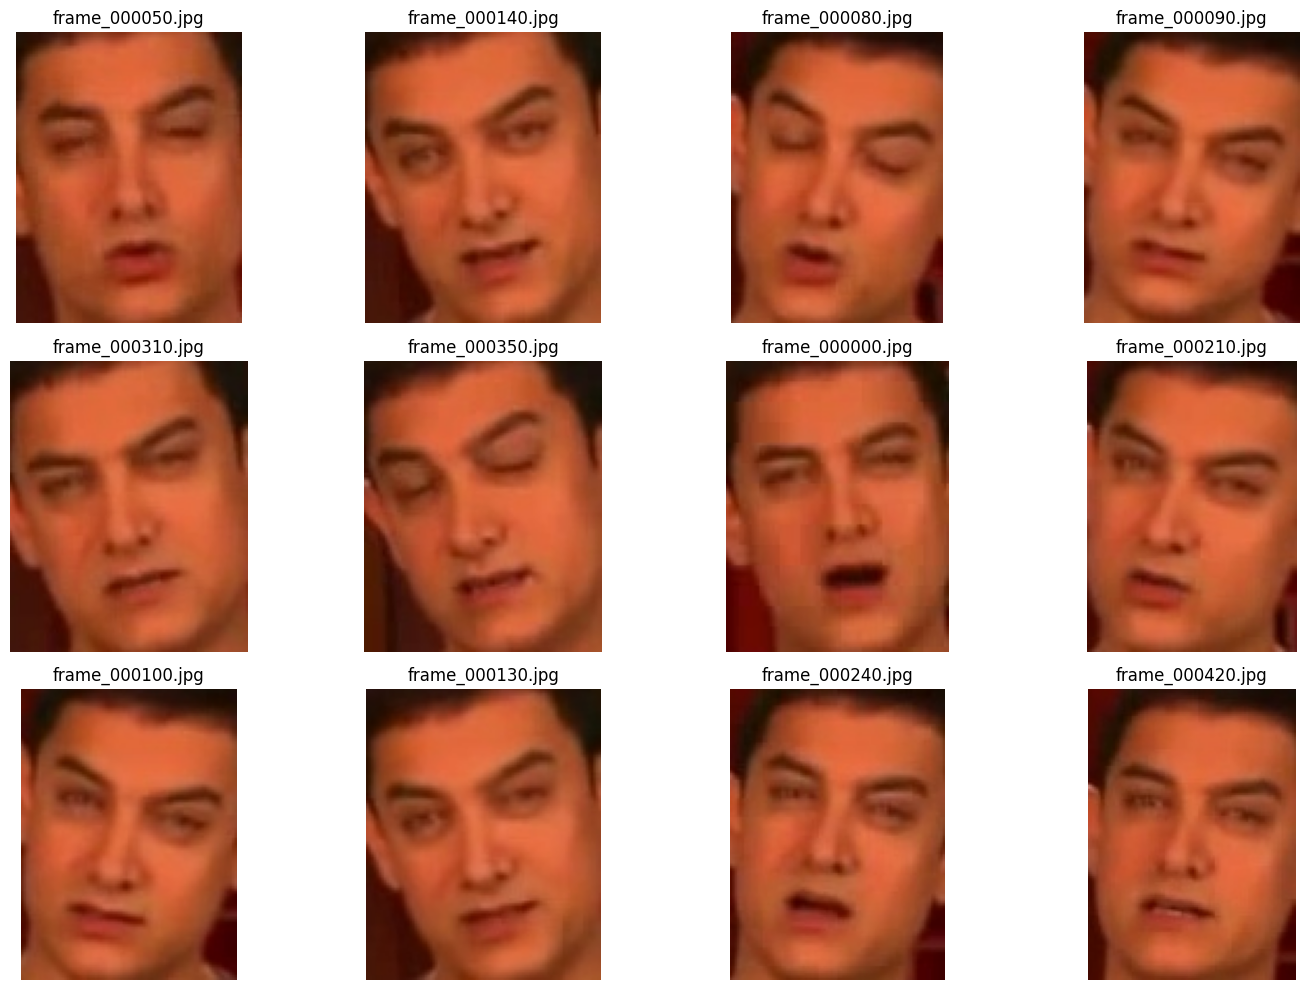

In [16]:
import os
import matplotlib.pyplot as plt
from PIL import Image

# Get some saved face images
face_images = []

for root, dirs, files in os.walk(FACES_DIR):
    for file in files:
        if file.endswith(".jpg"):
            face_images.append(os.path.join(root, file))

print("Total face crops found:", len(face_images))

# Show first 12
plt.figure(figsize=(15, 10))

for i, image_path in enumerate(face_images[:12]):
    image = Image.open(image_path)

    plt.subplot(3, 4, i + 1)
    plt.imshow(image)
    plt.axis("off")
    plt.title(os.path.basename(image_path))

plt.tight_layout()
plt.show()